In [ ]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict, List
from IPython.display import Image, display

urls = ["www.anthropic.com/engineering", "openai.com/news/"]

def controller(state: dict):
    return 'Done'

def research_url(state: dict):
    return

def research_outer(state: dict):
    return

def synthesize(state: dict):
    return

class ResearchState(TypedDict):
    llm_calls: int
    urls: List[str]

def decide_to_deep_dive(state: dict):
      if state.get("needs_deep_dive"):
          return "research_outer"
      else:
          return "controller"

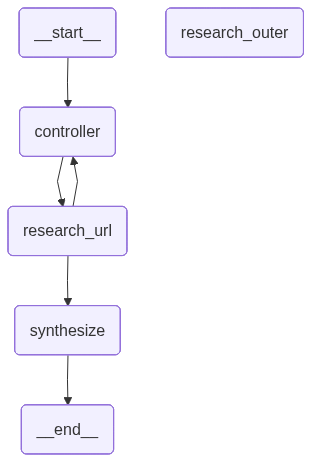

In [20]:
graph = StateGraph(ResearchState)
graph.add_node('controller', controller)
graph.add_node('research_url', research_url)
graph.add_node('research_outer', research_outer)
graph.add_node('synthesize', synthesize)

graph.add_edge(START, "controller")
graph.add_edge('controller', 'research_url')
graph.add_edge('research_url', 'controller')
graph.add_conditional_edges('research_url', decide_to_deep_dive)
# graph.add_edge('research_outer', 'needs_more_info')
graph.add_edge('research_url', 'synthesize')
graph.add_edge('synthesize', END)

compiled = graph.compile()

display(Image(compiled.get_graph().draw_mermaid_png()))